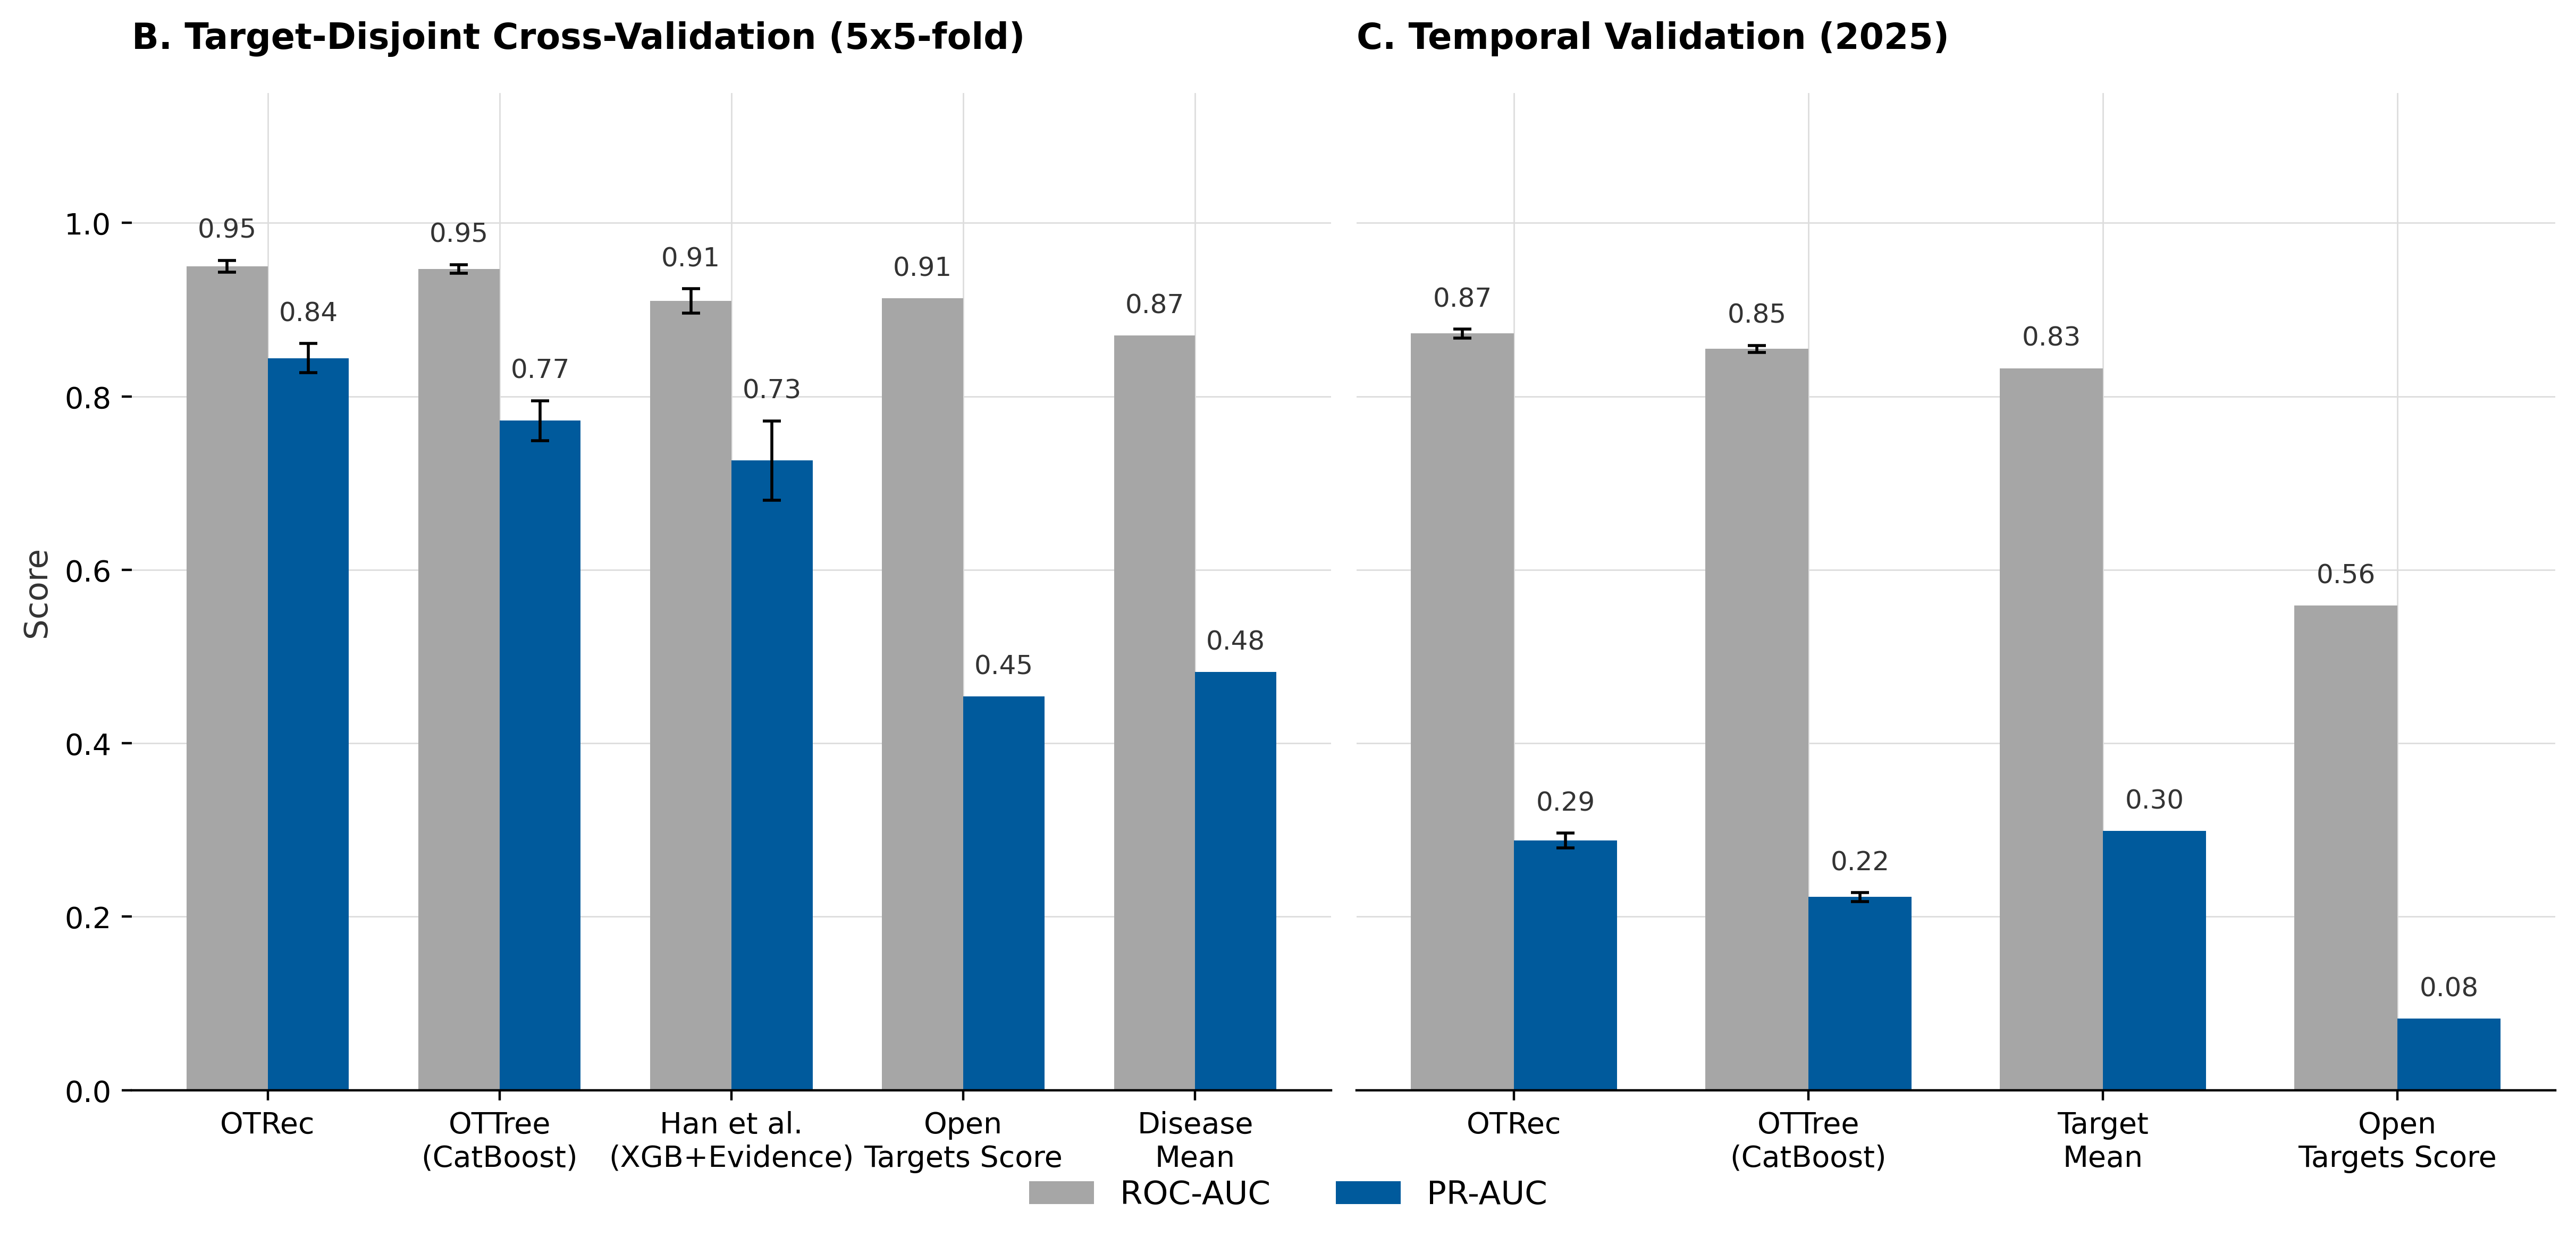

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Tufte-Style Configuration ---
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]
plt.rcParams["figure.dpi"] = 400
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.left"] = False  # Remove y-axis spine
plt.rcParams["axes.grid"] = True  # Keep grid
plt.rcParams["grid.color"] = "#dddddd"
plt.rcParams["grid.linestyle"] = "-"
plt.rcParams["grid.linewidth"] = 0.5
plt.rcParams["axes.axisbelow"] = True  # Grid behind bars

# --- Data ---
# Panel B: Cross-Validation
models_b = [
    "OTRec",
    "OTTree\n(CatBoost)",
    "Han et al.\n(XGB+Evidence)",
    "Open\nTargets Score",
    "Disease\nMean",
]
roc_b = [0.9499, 0.947, 0.910, 0.913, 0.870]
roc_sd_b = [0.007, 0.005, 0.0142, 0.0, 0.0]
pr_b = [0.844, 0.772, 0.726, 0.454, 0.482]
pr_sd_b = [0.017, 0.023, 0.0457, 0.0, 0.0]

# Panel C: Temporal Validation
panel_c_order = [
    "OTRec",
    "OTTree (CatBoost)",
    "Target Mean Baseline",
    "Open Targets Score",
]
panel_c_labels = {
    "OTRec": "OTRec",
    "OTTree (CatBoost)": "OTTree\n(CatBoost)",
    "Target Mean Baseline": "Target\nMean",
    "Open Targets Score": "Open\nTargets Score",
}
temporal_df = pd.read_csv("temporal_repeats_5seed/temporal_summary.csv")
temporal_df = temporal_df.set_index("Model").loc[panel_c_order].reset_index()
models_c = [panel_c_labels[model] for model in temporal_df["Model"]]
roc_c = temporal_df["ROC-AUC"].to_list()
roc_sd_c = temporal_df["ROC-AUC SD"].to_list()
pr_c = temporal_df["PR-AUC"].to_list()
pr_sd_c = temporal_df["PR-AUC SD"].to_list()

# --- Color Scheme ---
# Grey for Context (ROC), Oxford Blue for Signal (PR)
c_roc = "#A6A6A6"
c_pr = "#005A9C"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)


def plot_clean_bars(ax, models, rocs, roc_errs, prs, pr_errs, title, hide_y=False):
    x = np.arange(len(models))
    width = 0.35

    # Bars
    bars1 = ax.bar(x - width / 2, rocs, width, label="ROC-AUC", color=c_roc)
    bars2 = ax.bar(x + width / 2, prs, width, label="PR-AUC", color=c_pr)

    # Error Bars
    safe_roc_errs = roc_errs if roc_errs is not None else [0] * len(rocs)
    safe_pr_errs = pr_errs if pr_errs is not None else [0] * len(prs)

    for bar, err in zip(bars1, safe_roc_errs):
        if err > 0:
            ax.errorbar(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                yerr=err,
                fmt="none",
                ecolor="black",
                capsize=3,
                elinewidth=1,
            )
    for bar, err in zip(bars2, safe_pr_errs):
        if err > 0:
            ax.errorbar(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                yerr=err,
                fmt="none",
                ecolor="black",
                capsize=3,
                elinewidth=1,
            )

    # Data Labels
    def add_labels(bars, errs):
        for bar, err in zip(bars, errs):
            height = bar.get_height()
            if height < 0.02:
                continue
            y_pos = height + err + 0.02
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                y_pos,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="#333333",
            )

    add_labels(bars1, safe_roc_errs)
    add_labels(bars2, safe_pr_errs)

    # Styling
    ax.set_title(title, loc="left", fontsize=12, fontweight="bold", pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10, linespacing=1.2)
    ax.set_ylim(0, 1.15)

    if hide_y:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", length=0)
    else:
        ax.set_ylabel("Score", fontsize=11, color="#333333")


# Execute
plot_clean_bars(
    ax1,
    models_b,
    roc_b,
    roc_sd_b,
    pr_b,
    pr_sd_b,
    "B. Target-Disjoint Cross-Validation (5x5-fold)",
)
plot_clean_bars(
    ax2,
    models_c,
    roc_c,
    roc_sd_c,
    pr_c,
    pr_sd_c,
    "C. Temporal Validation (2025)",
    hide_y=True,
)

# Shared Legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=False,
    fontsize=11,
)

# Save
plt.savefig("Fig1_BC.png", dpi=400, bbox_inches="tight")
plt.show()